# PitIQ — Driver Style Fingerprints Validation

**Input:** `data/features/driver_styles.parquet` — 33 drivers × 10 style features computed in Phase 2.5.1.  
**Purpose:** Visually validate that the style features capture real, meaningful differences between drivers before they enter the XGBoost model in Phase 3.

**Sections:**
1. Style fingerprint summary table
2. Radar charts — 4 head-to-head comparisons
3. K-means clustering (optimal k via silhouette score)
4. Cluster sanity check — do clusters match real-world archetypes?
5. Pairwise feature correlation heatmap

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

matplotlib.rcParams.update({
    'figure.facecolor': '#0a0a0f',
    'axes.facecolor':   '#12121a',
    'axes.edgecolor':   '#2a2a3d',
    'axes.labelcolor':  '#f0f0f5',
    'xtick.color':      '#8888aa',
    'ytick.color':      '#8888aa',
    'text.color':       '#f0f0f5',
    'grid.color':       '#2a2a3d',
    'grid.linestyle':   '--',
    'legend.facecolor': '#1a1a26',
    'legend.edgecolor': '#2a2a3d',
    'figure.dpi':       120,
})

REPO_ROOT = Path('..').resolve()
styles = pd.read_parquet(REPO_ROOT / 'data/features/driver_styles.parquet')
styles = styles.sort_values('overall_pace_rank')  # best (lowest rank) first

FEATURES = [
    'pace_trend_soft', 'pace_trend_medium', 'pace_trend_hard',
    'cornering_aggression', 'throttle_smoothness',
    'wet_skill_delta', 'tire_saving_coef',
    'overall_pace_rank',
    'sector_relative_s1', 'sector_relative_s2', 'sector_relative_s3',
]

print(f'Loaded {len(styles)} drivers × {len(FEATURES)} features')
print(f'NaN counts: {styles[FEATURES].isna().sum().to_dict()}')

Loaded 33 drivers × 11 features
NaN counts: {'pace_trend_soft': 1, 'pace_trend_medium': 0, 'pace_trend_hard': 2, 'cornering_aggression': 0, 'throttle_smoothness': 0, 'wet_skill_delta': 1, 'tire_saving_coef': 0, 'overall_pace_rank': 0, 'sector_relative_s1': 0, 'sector_relative_s2': 0, 'sector_relative_s3': 0}


---
## 1. Style Fingerprint Summary Table

**What to look for:** Clear value gradients within each column — darker colours at one end, lighter at the other. If a column is uniform (all same shade), that feature has low variance across drivers and may not contribute signal in Phase 3.  
**Expected patterns:**
- `sector_profile_*`: VER should be deep green (low rank = fast); MAZ should be deep red.
- `wet_skill_delta`: VER, NOR, PIA should be green (negative = faster in wet); MAZ, SAR should be red.
- `cornering_aggression` / `throttle_smoothness`: should show visible spread — if all values look uniform, the telemetry summary columns lack driver discrimination power.
- `tire_saving_coef`: likely uniform (low variance confirmed in 2.5.1) — this is expected.

Sorted by `sector_profile_avg` (best → worst) to put the fastest drivers at the top.

In [2]:
display_cols = FEATURES

def color_col(s):
    name = s.name
    # Red = worse/higher for features where lower is better
    if any(x in name for x in ['overall_pace_rank', 'wet_skill', 'pace_trend']):
        return ['background-color: rgba(232,0,45,{:.2f})'.format(0.7*v) if not pd.isna(v)
                else 'background-color: #333344'
                for v in (s - s.min()) / (s.max() - s.min() + 1e-9)]
    # sector_relative: near-zero is neutral; extremes in either direction are notable
    elif 'sector_relative' in name:
        mid = (s - s.mean()) / (s.std() + 1e-9)
        return ['background-color: rgba(54,113,198,{:.2f})'.format(min(0.7, abs(v)*0.35))
                if not pd.isna(v) else 'background-color: #333344'
                for v in mid]
    else:
        return ['background-color: rgba(54,113,198,{:.2f})'.format(0.7*v) if not pd.isna(v)
                else 'background-color: #333344'
                for v in (s - s.min()) / (s.max() - s.min() + 1e-9)]

table = styles[display_cols].copy()
fmt = {
    'pace_trend_soft':       '{:+.3f}',
    'pace_trend_medium':     '{:+.3f}',
    'pace_trend_hard':       '{:+.3f}',
    'cornering_aggression':  '{:.2f}',
    'throttle_smoothness':   '{:.4f}',
    'wet_skill_delta':       '{:+.3f}',
    'tire_saving_coef':      '{:.4f}',
    'overall_pace_rank':     '{:.2f}',
    'sector_relative_s1':    '{:+.3f}',
    'sector_relative_s2':    '{:+.3f}',
    'sector_relative_s3':    '{:+.3f}',
}
styled = (table.style
               .apply(color_col)
               .format(fmt, na_rep='NaN')
               .set_caption('Driver Style Fingerprints — sorted by overall_pace_rank (best → worst)'))
display(styled)

,pace_trend_soft,pace_trend_medium,pace_trend_hard,cornering_aggression,throttle_smoothness,wet_skill_delta,tire_saving_coef,overall_pace_rank,sector_relative_s1,sector_relative_s2,sector_relative_s3
Driver,,,,,,,,,,,
VER,-0.502,-0.257,+0.140,19.31,0.1975,-1.113,0.9908,4.22,+0.208,-0.397,+0.188
LEC,-0.425,-0.338,-0.050,20.37,0.1676,-0.647,0.9903,6.02,+0.152,-0.242,+0.090
PER,-0.535,-0.448,+0.100,20.29,0.2001,-0.538,0.9901,6.06,-0.018,-0.336,+0.355
HAM,-0.575,-0.251,+0.022,20.60,0.1642,-0.379,0.9926,6.13,+0.043,+0.083,-0.126
PIA,-0.462,-0.097,-0.121,18.67,0.2009,-0.677,0.9916,6.42,+0.107,-0.061,-0.047
NOR,-0.457,-0.163,+0.396,19.50,0.1882,-0.777,0.9914,6.51,+0.318,+0.020,-0.339
SAI,-0.527,-0.132,-0.333,21.43,0.1869,-0.368,0.9914,7.11,+0.150,-0.063,-0.087
RUS,-0.231,-0.338,-0.159,19.81,0.1866,-0.287,0.9927,7.61,+0.085,+0.012,-0.097
ANT,-0.528,+0.243,-0.092,19.93,0.1968,-0.160,0.9934,8.13,-0.489,+0.329,+0.160


---
## 2. Radar Charts — Driver Style Vectors

**Normalisation:** All features scaled to [0, 1] across the driver population. For features where **lower = better** (sector ranks, wet_skill_delta, pace_trends), the scale is inverted so that **outward = higher performance / stronger expression of that trait**. NaNs are imputed to the population mean before scaling.

**Feature directions on the radar (outward = more):**
- `pace trend S/M/H` → inverted: outward = less net pace loss on that compound
- `cornering aggression` → outward = harder braker
- `throttle smoothness` → outward = smoother throttle application
- `wet skill` → inverted: outward = faster vs race peers in wet
- `tire saving` → outward = more early-stint pacing
- `sector S1/S2/S3` → inverted: outward = better average rank in that sector

**Four comparisons:**
1. **VER vs HAM** — Expected: VER larger overall polygon (better sector ranks); similar shape overall but differences in wet skill and pace trends
2. **LEC vs SAI** — Teammates at Ferrari 2021–2024; expected to look similar but LEC edges SAI on sector ranks, SAI may show different pace trends
3. **ZHO vs HUL** — HUL is the midfield veteran (cleaner shape); ZHO expected to show poor wet skill (outward = inverted, so ZHO will be *smaller* on wet axis)
4. **NOR vs PIA** — McLaren teammates 2023–2025; expected very similar polygons — if radically different, something is wrong

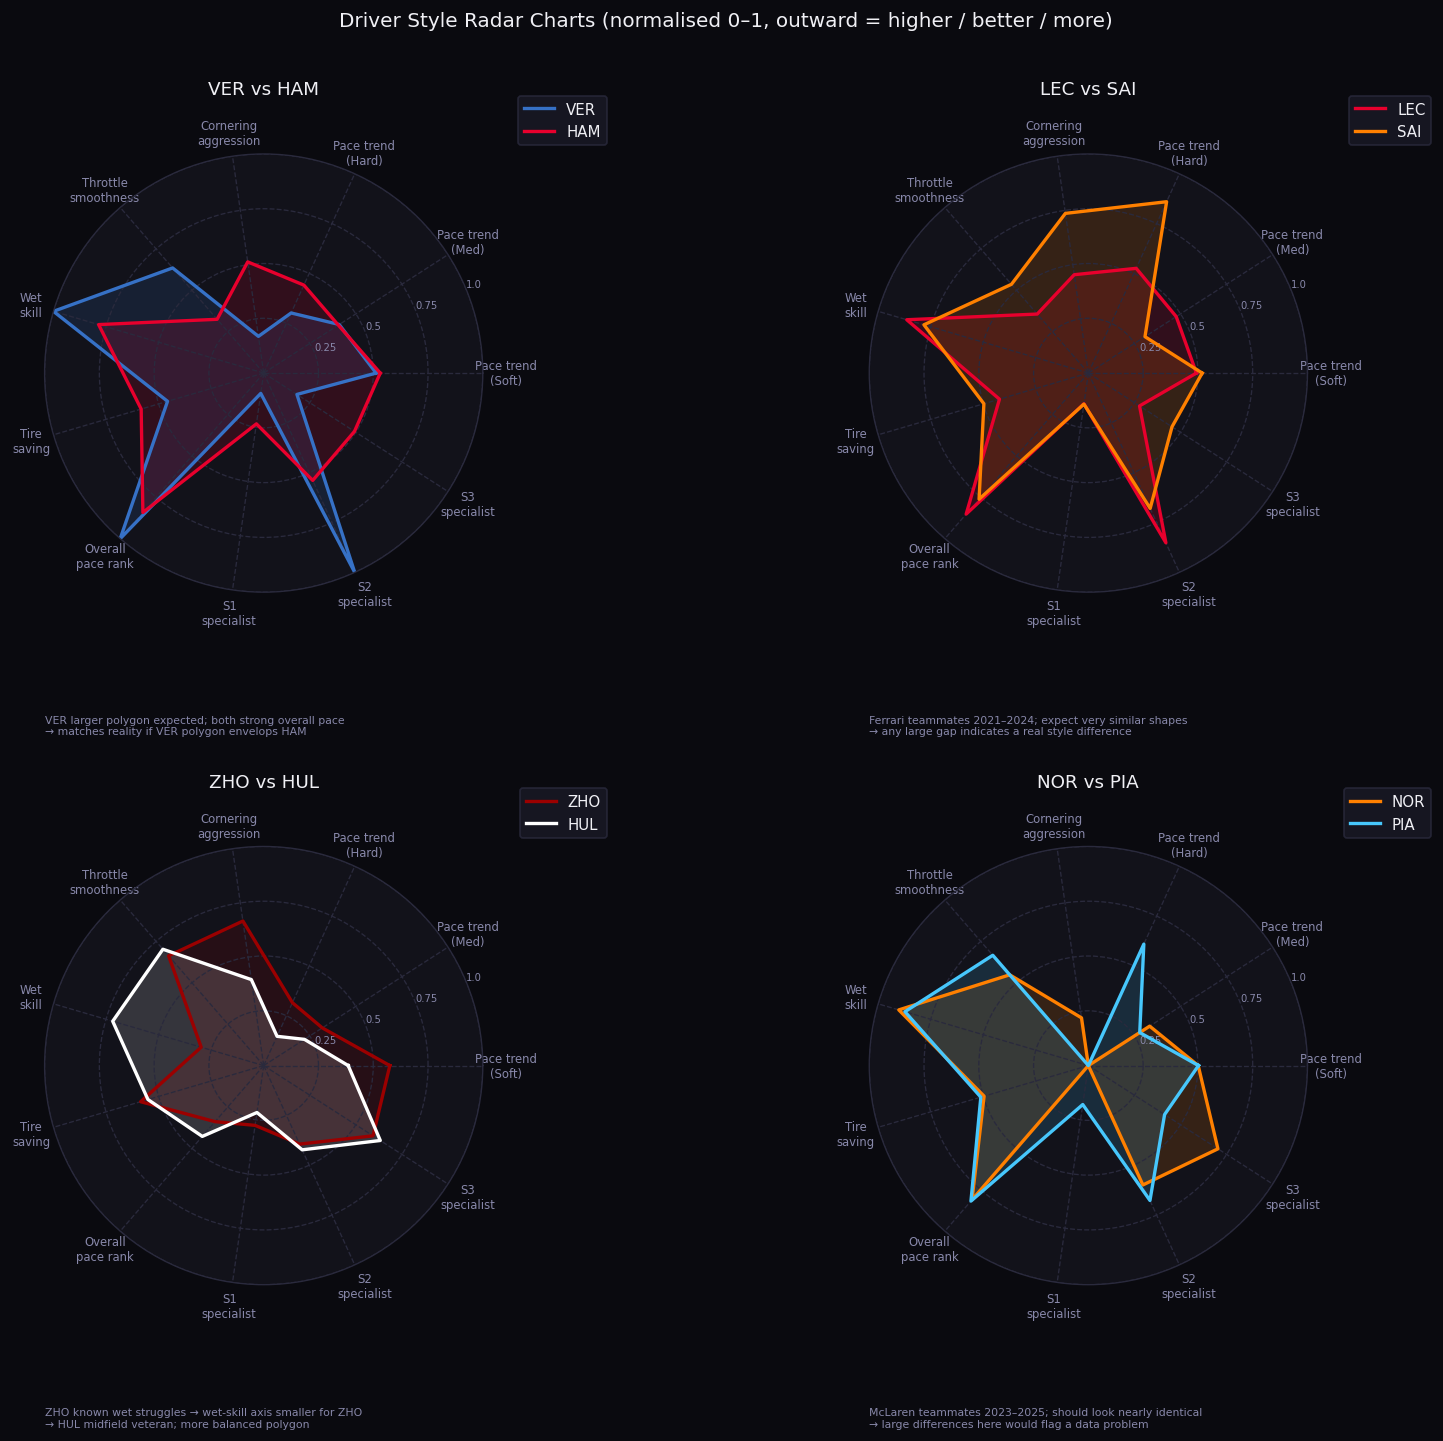

In [3]:
RADAR_FEATURES = [
    'pace_trend_soft', 'pace_trend_medium', 'pace_trend_hard',
    'cornering_aggression', 'throttle_smoothness',
    'wet_skill_delta', 'tire_saving_coef',
    'overall_pace_rank',
    'sector_relative_s1', 'sector_relative_s2', 'sector_relative_s3',
]
RADAR_LABELS = [
    'Pace trend\n(Soft)', 'Pace trend\n(Med)', 'Pace trend\n(Hard)',
    'Cornering\naggression', 'Throttle\nsmoothness',
    'Wet\nskill', 'Tire\nsaving',
    'Overall\npace rank',
    'S1\nspecialist', 'S2\nspecialist', 'S3\nspecialist',
]
# Features where lower raw value = better / more positive trait → invert for outward = better
INVERT = {'pace_trend_soft', 'pace_trend_medium', 'pace_trend_hard',
          'wet_skill_delta', 'overall_pace_rank',
          'sector_relative_s1', 'sector_relative_s2', 'sector_relative_s3'}

raw    = styles[RADAR_FEATURES].copy()
imputed = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(raw),
                       index=raw.index, columns=raw.columns)
normed  = pd.DataFrame(MinMaxScaler().fit_transform(imputed),
                       index=imputed.index, columns=imputed.columns)
for col in INVERT:
    normed[col] = 1.0 - normed[col]

COMPARISONS = [
    ('VER', 'HAM', '#3671C6', '#E8002D',
     'VER larger polygon expected; both strong overall pace\n→ matches reality if VER polygon envelops HAM'),
    ('LEC', 'SAI', '#E8002D', '#FF8000',
     'Ferrari teammates 2021–2024; expect very similar shapes\n→ any large gap indicates a real style difference'),
    ('ZHO', 'HUL', '#9B0000', '#FFFFFF',
     'ZHO known wet struggles → wet-skill axis smaller for ZHO\n→ HUL midfield veteran; more balanced polygon'),
    ('NOR', 'PIA', '#FF8000', '#47C7FC',
     'McLaren teammates 2023–2025; should look nearly identical\n→ large differences here would flag a data problem'),
]

N = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12),
                          subplot_kw=dict(polar=True),
                          facecolor='#0a0a0f')
axes = axes.flatten()

for ax, (d1, d2, c1, c2, note) in zip(axes, COMPARISONS):
    ax.set_facecolor('#12121a')
    for driver, color in [(d1, c1), (d2, c2)]:
        vals = normed.loc[driver, RADAR_FEATURES].tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=driver)
        ax.fill(angles, vals, color=color, alpha=0.15)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, size=7, color='#8888aa')
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=6, color='#555566')
    ax.set_ylim(0, 1)
    ax.spines['polar'].set_color('#2a2a3d')
    ax.tick_params(colors='#8888aa')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)
    ax.set_title(f'{d1} vs {d2}', pad=15, fontsize=11, color='#f0f0f5')
    ax.text(0, -0.28, note, transform=ax.transAxes,
            fontsize=6.5, color='#8888aa', ha='left', va='top')

plt.suptitle('Driver Style Radar Charts (normalised 0–1, outward = higher / better / more)',
             y=1.01, fontsize=12, color='#f0f0f5')
plt.tight_layout()
plt.show()

---
## 3. K-Means Clustering

**What to look for:** Silhouette score should peak clearly at one value of k — that's the natural number of driver archetypes in the data. A silhouette score > 0.25 is acceptable; > 0.4 is good for a 10-dimensional feature space.  
**Expected clusters:** Roughly:
- Cluster A: top-tier all-rounders (VER, NOR, LEC, HAM, PIA)
- Cluster B: solid midfielders (ALO, SAI, RUS, GAS, etc.)
- Cluster C: back-of-grid / struggling (MAZ, SAR, MSC, ZHO, etc.)

A 4th cluster might split out wet specialists or drivers with unusual style signatures.  
**Red flag:** If the PCA plot shows all drivers in one blob with no structure, the features aren't discriminating enough to cluster meaningfully.

Silhouette scores:
  k=3: 0.1125
  k=4: 0.1508 ← best
  k=5: 0.1330


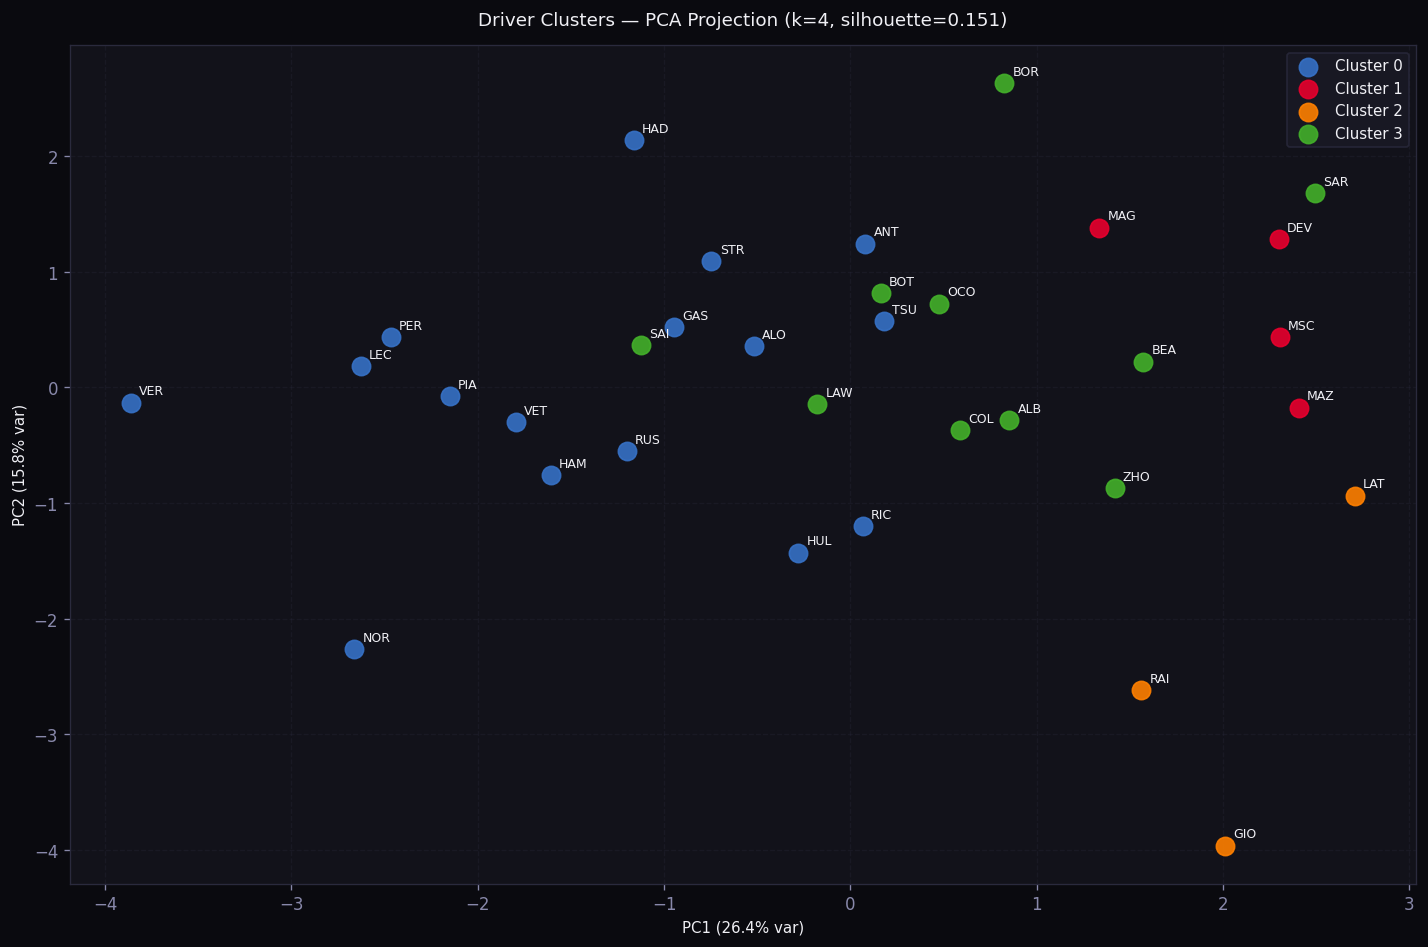


PC1 explains 26.4% of variance
PC2 explains 15.8% of variance
Combined: 42.2%


In [4]:
# Standardize (z-score) for clustering — preserves variance structure better than min-max
from sklearn.preprocessing import StandardScaler

X_imp = pd.DataFrame(
    SimpleImputer(strategy='mean').fit_transform(styles[FEATURES]),
    index=styles.index, columns=FEATURES
)
X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_imp),
    index=styles.index, columns=FEATURES
)

# Silhouette scores for k = 3..5
sil_scores = {}
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(sil_scores, key=sil_scores.get)
print('Silhouette scores:')
for k, s in sil_scores.items():
    marker = ' ← best' if k == best_k else ''
    print(f'  k={k}: {s:.4f}{marker}')

# Fit with best k
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=20)
styles['cluster'] = km_best.fit_predict(X_scaled)

# PCA 2D projection
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

CLUSTER_COLORS = ['#3671C6', '#E8002D', '#FF8000', '#43B02A', '#9B0000']

fig, ax = plt.subplots(figsize=(12, 8))
for c in range(best_k):
    mask = styles['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=CLUSTER_COLORS[c], s=120, alpha=0.9,
               label=f'Cluster {c}', zorder=3)

for i, driver in enumerate(styles.index):
    ax.annotate(driver, (coords[i, 0], coords[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=7.5, color='#f0f0f5', zorder=4)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% var)', fontsize=9)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% var)', fontsize=9)
ax.set_title(f'Driver Clusters — PCA Projection (k={best_k}, silhouette={sil_scores[best_k]:.3f})',
             pad=12, fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nPC1 explains {var_explained[0]*100:.1f}% of variance')
print(f'PC2 explains {var_explained[1]*100:.1f}% of variance')
print(f'Combined: {sum(var_explained)*100:.1f}%')

---
## 4. Cluster Sanity Check

**What to look for:** Each cluster should correspond to a recognisable real-world driver archetype.  
- The cluster with lowest avg sector rank and most negative avg wet_skill_delta = top-tier all-rounders.
- The cluster with highest avg sector rank = backmarkers.
- Intermediate clusters = midfield, possibly split by style (aggressive vs conservative).

**Red flag:** Verstappen and Mazepin in the same cluster — that would mean sector ranks aren't dominating the clustering and the features are not discriminating on quality. If you see this, the scale of a non-sector feature is swamping the signal.

In [5]:
summary_cols = ['overall_pace_rank', 'wet_skill_delta', 'cornering_aggression',
                'throttle_smoothness', 'pace_trend_medium']

print('=== Cluster Membership ===')
for c in sorted(styles['cluster'].unique()):
    members = styles[styles['cluster'] == c].index.tolist()
    print(f'\nCluster {c} ({len(members)} drivers): {" | ".join(members)}')

print('\n=== Cluster Feature Averages ===')
cluster_means = styles.groupby('cluster')[summary_cols].mean().round(3)
cluster_means.columns = ['avg_pace_rank', 'avg_wet_delta', 'avg_braking', 'avg_smoothness', 'avg_pace_trend_med']
print(cluster_means.to_string())

print('\n=== Most Extreme Drivers per Cluster ===')
for c in sorted(styles['cluster'].unique()):
    grp = styles[styles['cluster'] == c]
    best_sector  = grp['overall_pace_rank'].idxmin()
    worst_sector = grp['overall_pace_rank'].idxmax()
    best_wet  = grp['wet_skill_delta'].idxmin() if grp['wet_skill_delta'].notna().any() else 'N/A'
    worst_wet = grp['wet_skill_delta'].idxmax() if grp['wet_skill_delta'].notna().any() else 'N/A'
    print(f'\nCluster {c}:')
    print(f'  Best overall pace:  {best_sector} (rank {grp.loc[best_sector, "overall_pace_rank"]:.2f})')
    print(f'  Worst overall pace: {worst_sector} (rank {grp.loc[worst_sector, "overall_pace_rank"]:.2f})')
    if best_wet != 'N/A':
        print(f'  Best wet skill:     {best_wet} ({grp.loc[best_wet, "wet_skill_delta"]:+.3f}s)')
        print(f'  Worst wet skill:    {worst_wet} ({grp.loc[worst_wet, "wet_skill_delta"]:+.3f}s)')

=== Cluster Membership ===

Cluster 0 (16 drivers): VER | LEC | PER | HAM | PIA | NOR | RUS | ANT | ALO | VET | GAS | HAD | RIC | STR | TSU | HUL

Cluster 1 (4 drivers): MAG | DEV | MSC | MAZ

Cluster 2 (3 drivers): RAI | GIO | LAT

Cluster 3 (10 drivers): SAI | BEA | BOT | OCO | ALB | LAW | BOR | ZHO | COL | SAR

=== Cluster Feature Averages ===
         avg_pace_rank  avg_wet_delta  avg_braking  avg_smoothness  avg_pace_trend_med
cluster                                                                               
0                8.468         -0.255       19.840           0.184              -0.199
1               13.659          1.511       20.140           0.205              -0.304
2               11.734          0.492       21.479           0.226              -0.641
3               11.104          0.626       21.399           0.195              -0.090

=== Most Extreme Drivers per Cluster ===

Cluster 0:
  Best overall pace:  VER (rank 4.22)
  Worst overall pace: HUL (rank 11.15

---
## 5. Pairwise Feature Correlation Heatmap

**What to look for:**
- `throttle_smoothness` vs `cornering_aggression`: expect **moderate negative correlation** — drivers who apply brakes harder tend to be less smooth on throttle.
- `pace_trend_soft` vs `pace_trend_medium` vs `pace_trend_hard`: expect **positive correlations** — a driver who manages one compound well tends to manage all compounds well.
- `wet_skill_delta` vs sector ranks (`sector_profile_*`): expect **weak/no correlation** — being fast in wet is a distinct skill from overall pace, so these should be mostly independent.
- `tire_saving_coef` vs anything: likely near-zero correlations due to low feature variance — this is expected and confirms the earlier low-variance observation.

**Red flag:** `sector_profile_*` and `wet_skill_delta` showing strong correlation (> |0.6|) would mean wet skill is just a proxy for overall pace, not an independent feature — in that case it adds no information beyond sector ranks.

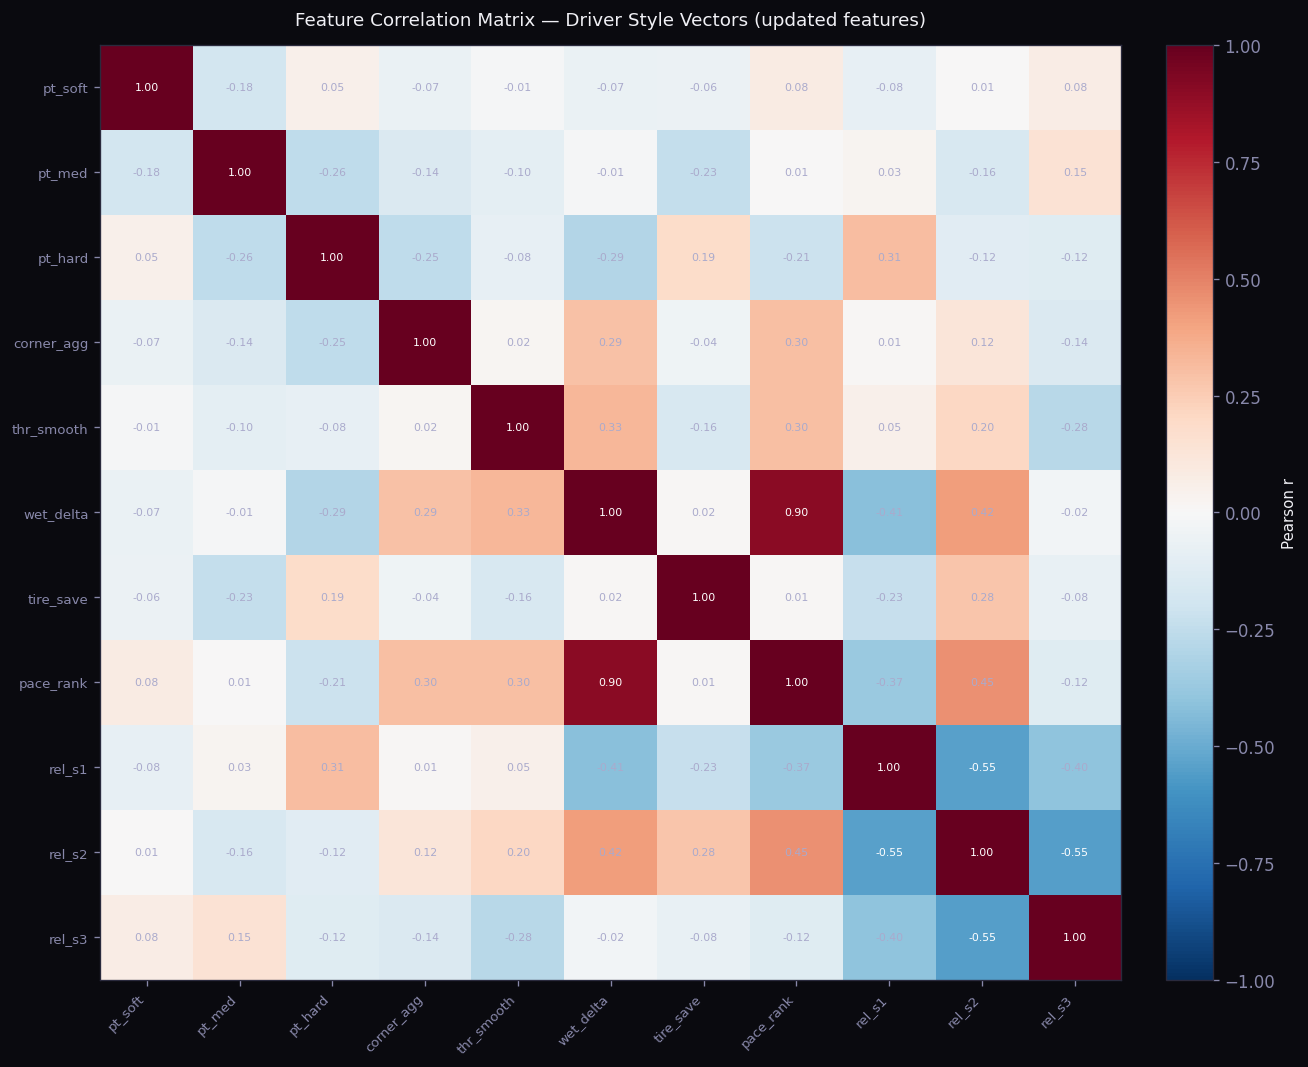

Notable correlations (|r| > 0.4, excluding diagonal):
  wet_skill_delta              vs overall_pace_rank             r = +0.901
  wet_skill_delta              vs sector_relative_s1            r = -0.414
  wet_skill_delta              vs sector_relative_s2            r = +0.417
  overall_pace_rank            vs sector_relative_s2            r = +0.454
  sector_relative_s1           vs sector_relative_s2            r = -0.546
  sector_relative_s1           vs sector_relative_s3            r = -0.401
  sector_relative_s2           vs sector_relative_s3            r = -0.549

Sector relative inter-correlations:
  sector_relative_s1 vs sector_relative_s2: r = -0.546
  sector_relative_s1 vs sector_relative_s3: r = -0.401
  sector_relative_s2 vs sector_relative_s3: r = -0.549


In [6]:
corr = styles[FEATURES].corr()

short_labels = [
    'pt_soft', 'pt_med', 'pt_hard',
    'corner_agg', 'thr_smooth',
    'wet_delta', 'tire_save',
    'pace_rank',
    'rel_s1', 'rel_s2', 'rel_s3',
]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        val = corr.values[i, j]
        text_color = 'white' if abs(val) > 0.5 else '#aaaacc'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6.5, color=text_color)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('Pearson r', fontsize=9)
ax.set_title('Feature Correlation Matrix — Driver Style Vectors (updated features)', pad=12, fontsize=11)
plt.tight_layout()
plt.show()

print('Notable correlations (|r| > 0.4, excluding diagonal):')
for i, f1 in enumerate(FEATURES):
    for j, f2 in enumerate(FEATURES):
        if i >= j:
            continue
        r = corr.loc[f1, f2]
        if abs(r) > 0.4:
            print(f'  {f1:<28} vs {f2:<28}  r = {r:+.3f}')

print('\nSector relative inter-correlations:')
for a, b in [('sector_relative_s1','sector_relative_s2'),
             ('sector_relative_s1','sector_relative_s3'),
             ('sector_relative_s2','sector_relative_s3')]:
    print(f'  {a} vs {b}: r = {corr.loc[a,b]:+.3f}')